In [2]:
# %%
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Loading PUMS Data...")
DATA_RAW = os.path.join("..", "data", "raw")

# Load all household and person files
h_files = glob.glob(os.path.join(DATA_RAW, "psam_h*.csv"))
p_files = glob.glob(os.path.join(DATA_RAW, "psam_p*.csv"))

if h_files and p_files:
    df_h_raw = pd.concat([pd.read_csv(f) for f in h_files], ignore_index=True)
    df_p_raw = pd.concat([pd.read_csv(f) for f in p_files], ignore_index=True)
    
    # Merge on SERIALNO
    df_flat = pd.merge(df_p_raw, df_h_raw, on='SERIALNO', how='inner')
    print(f"✅ Merged Data Ready! Shape: {df_flat.shape}")
else:
    print("❌ Missing PUMS files. Please check your data/raw folder.")

🚀 Loading PUMS Data...
✅ Merged Data Ready! Shape: (157694, 527)


In [3]:
# %%
print("🧹 Cleaning Data & Dropping Unnecessary Columns...")

# 1. Drop imputed SNAP data to ensure ground-truth for our model
df_clean = df_flat[df_flat['FFSP'] != 1].copy()

# 2. Identify and drop replicate weights (WGTP, PWGTP). 
# The Census uses these (over 160 columns!) for complex variance estimation. We don't need them for ML.
weight_cols = [c for c in df_clean.columns if c.startswith('PWGTP') or c.startswith('WGTP')]

# We also drop the statistical allocation flags (columns starting with 'F' that indicate Census imputation)
# Exception: We keep 'FS' (SNAP outcome) and 'FFSP' (which we just used).
alloc_flags = [c for c in df_clean.columns if c.startswith('F') and c not in ['FS', 'FFSP', 'FES', 'FPARC', 'FOD1P', 'FOD2P']]

cols_to_drop = weight_cols + alloc_flags
df_eda = df_clean.drop(columns=cols_to_drop, errors='ignore')

# 3. Output the final list of columns available for your ML model
kept_columns = df_eda.columns.tolist()
print(f"✅ Kept {len(kept_columns)} Columns for ML Mapping:\n")
print(kept_columns)

🧹 Cleaning Data & Dropping Unnecessary Columns...
✅ Kept 228 Columns for ML Mapping:

['RT_x', 'SERIALNO', 'DIVISION_x', 'SPORDER', 'PUMA_x', 'REGION_x', 'STATE_x', 'ADJINC_x', 'AGEP', 'CIT', 'CITWP', 'COW', 'DDRS', 'DEAR', 'DEYE', 'DOUT', 'DPHY', 'DRAT', 'DRATX', 'DREM', 'ENG', 'GCL', 'GCM', 'GCR', 'HIMRKS', 'HINS1', 'HINS2', 'HINS3', 'HINS4', 'HINS5', 'HINS6', 'HINS7', 'INTP', 'JWMNP', 'JWRIP', 'JWTRNS', 'LANX', 'MAR', 'MARHD', 'MARHM', 'MARHT', 'MARHW', 'MARHYP', 'MIG', 'MIL', 'MLPA', 'MLPB', 'MLPCD', 'MLPE', 'MLPFG', 'MLPH', 'MLPIK', 'MLPJ', 'NWAB', 'NWAV', 'NWLA', 'NWLK', 'NWRE', 'OIP', 'PAP', 'RELSHIPP', 'RETP', 'SCH', 'SCHG', 'SCHL', 'SEMP', 'SEX', 'SSIP', 'SSP', 'WAGP', 'WKHP', 'WKL', 'WKWN', 'WRK', 'YOEP', 'ANC', 'ANC1P', 'ANC2P', 'DECADE', 'DIS', 'DRIVESP', 'ESP', 'ESR', 'FOD1P', 'FOD2P', 'HICOV', 'HISP', 'INDP', 'JWAP', 'JWDP', 'LANP', 'MIGPUMA', 'MIGSP', 'MSP', 'NAICSP', 'NATIVITY', 'NOP', 'OC', 'OCCP', 'PAOC', 'PERNP', 'PINCP', 'POBP', 'POVPIP', 'POWPUMA', 'POWSP', 'PRIVCO

/var/folders/0s/d2ycgfq576zdm73qwlf4r6gc0000gn/T/ipykernel_67744/3659049268.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=hh_sizes, palette="viridis")


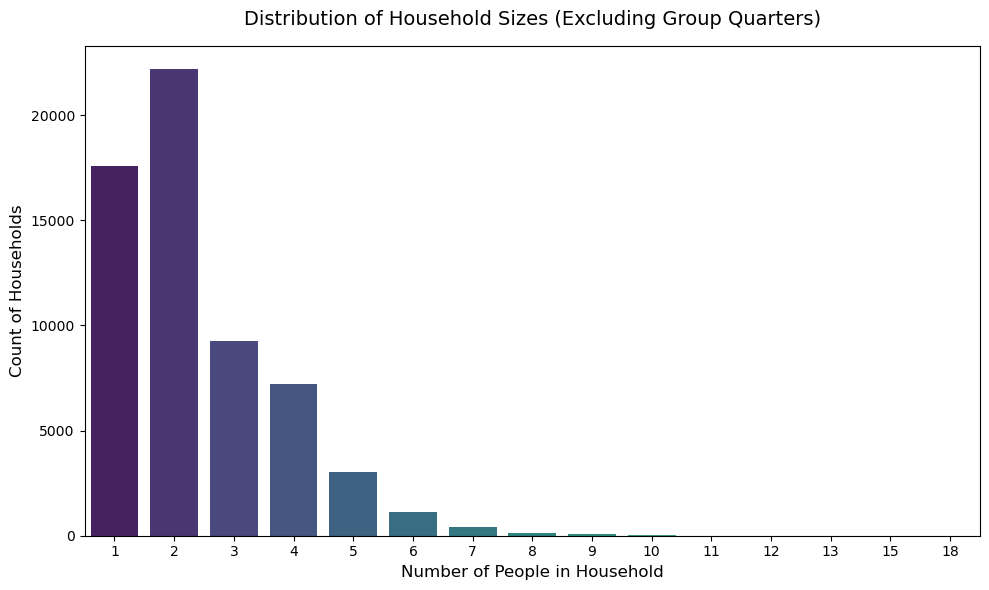

In [4]:
# %%
# Filter out Group Quarters (GQ) to only look at standard households
df_standard_people = df_eda[~df_eda['SERIALNO'].astype(str).str.contains('GQ')].copy()

# Count the number of people in each household
hh_sizes = df_standard_people.groupby('SERIALNO').size()

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.countplot(x=hh_sizes, palette="viridis")
plt.title('Distribution of Household Sizes (Excluding Group Quarters)', fontsize=14, pad=15)
plt.xlabel('Number of People in Household', fontsize=12)
plt.ylabel('Count of Households', fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# %%
# To get accurate household-level counts, we drop duplicate people in the same house
df_hh_level = df_eda.drop_duplicates(subset=['SERIALNO']).copy()

# 1. Total and Discarded Group Quarters (GQ)
total_households = len(df_hh_level)
gq_mask = df_hh_level['SERIALNO'].astype(str).str.contains('GQ')
gq_count = gq_mask.sum()

# 2. Filter to just standard households for SNAP logic
df_hh_std = df_hh_level[~gq_mask].copy()

# 3. Calculate the core metrics (FS == 1 is Claiming, FS == 2 is Not Claiming)
claiming = (df_hh_std['FS'] == 1.0).sum()
strict_eligible = (df_hh_std['POVPIP'] <= 130).sum()
gap = ((df_hh_std['POVPIP'] <= 130) & (df_hh_std['FS'] == 2.0)).sum()

# Validating your insight: Claiming SNAP despite gross income > 130% poverty
categorical_eligible = ((df_hh_std['POVPIP'] > 130) & (df_hh_std['FS'] == 1.0)).sum()

# 4. Print Results
print("📊 DATASET COUNTS (HOUSEHOLD LEVEL):")
print(f"Total Unique Households loaded:  {total_households:,}")
print(f"Discarded Group Quarters (GQ):   {gq_count:,}")
print(f"Valid Standard Households:       {len(df_hh_std):,}")
print("-" * 45)
print(f"Total Claiming SNAP:             {claiming:,}")
print(f"Strictly Eligible (<=130%):      {strict_eligible:,}")
print(f"🔴 THE GAP (<=130% & No SNAP):   {gap:,}")
print(f"🔵 Claiming but >130% Income:    {categorical_eligible:,}")
print("-" * 45)
print("💡 Note: The 'Claiming but >130% Income' group confirms your suspicion.")
print("These are households legally eligible through Broad-Based Categorical Eligibility (BBCE)")
print("or net-income deductions (e.g., households with elderly or disabled members).")

📊 DATASET COUNTS (HOUSEHOLD LEVEL):
Total Unique Households loaded:  67,057
Discarded Group Quarters (GQ):   5,986
Valid Standard Households:       61,071
---------------------------------------------
Total Claiming SNAP:             5,177
Strictly Eligible (<=130%):      7,450
🔴 THE GAP (<=130% & No SNAP):   4,929
🔵 Claiming but >130% Income:    2,656
---------------------------------------------
💡 Note: The 'Claiming but >130% Income' group confirms your suspicion.
These are households legally eligible through Broad-Based Categorical Eligibility (BBCE)
or net-income deductions (e.g., households with elderly or disabled members).
